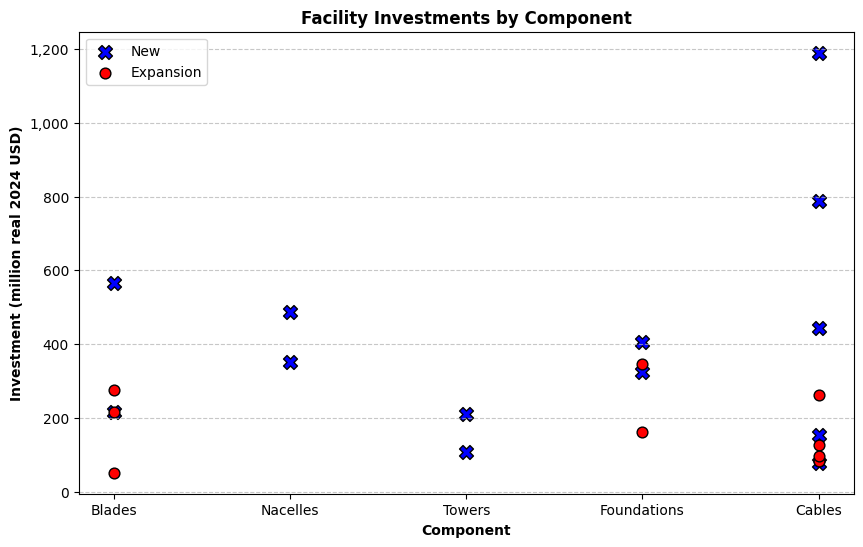

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def plot_facility_investments(file_path):
    # Load the dataset
    df = pd.read_csv(file_path)  # Assuming tab-separated values
    
    # Filter out rows where 'Investment (million real 2024 USD)' is missing
    df = df[df['Investment (million real 2024 USD)'].notna()]
    df['Investment (million real 2024 USD)'] = df['Investment (million real 2024 USD)'].astype(float)

    
    # Create the scatter plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot new facilities with 'X' marker
    new_facilities = df[df['New or Expansion'] == 'New']
    ax.scatter(new_facilities['Component'], new_facilities['Investment (million real 2024 USD)'], 
               marker='X', color='b', s = 100, edgecolors='black', label='New')
    
    # Plot expansion facilities with 'O' marker
    expansion_facilities = df[df['New or Expansion'] == 'Expansion']
    ax.scatter(expansion_facilities['Component'], expansion_facilities['Investment (million real 2024 USD)'], 
               marker='o', color='r', s = 60, edgecolors='black', label='Expansion')
    
    # Labels and title
    ax.set_xlabel('Component', fontweight='bold')
    ax.set_ylabel('Investment (million real 2024 USD)', fontweight='bold')
    ax.set_title('Facility Investments by Component', fontweight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend()
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=0, ha='center')
    plt.savefig("figures/expansion_new_investments.svg", format="svg", dpi=300)
    
    
    # Show plot
    plt.show()

# Example usage
plot_facility_investments('data/facility_investments.csv')

In [15]:
import pandas as pd

def process_facility_investments(file_path):
    # Load data
    df = pd.read_csv(file_path)
    
    # Filter out rows with missing investment values
    df = df[df['Investment (million real 2024 USD)'].notna()]
    
    # Pivot table to make components columns
    pivot_df = df.pivot_table(index='New or Expansion', columns='Component', 
                              values='Investment (million real 2024 USD)', aggfunc='mean')
    
    # Compute overall averages
    avg_new = pivot_df.loc['New'].mean()
    avg_expansion = pivot_df.loc['Expansion'].mean()
    new_to_exp_ratio = avg_new / avg_expansion
    
    # Append summary rows
    summary_df = pd.DataFrame({
        'Blades': [pivot_df['Blades'].mean(), None, None],
        'Cables': [pivot_df['Cables'].mean(), None, None],
        'Foundations': [pivot_df['Foundations'].mean(), None, None],
        'Nacelles': [pivot_df['Nacelles'].mean(), None, None],
        'Towers': [pivot_df['Towers'].mean(), None, None]
    }, index=['Average for New Investments', 'Average for Expansion Investments', 'New-to-Expansion Ratio'])
    
    summary_df.loc['Average for Expansion Investments'] = pivot_df.loc['Expansion'].mean()
    summary_df.loc['New-to-Expansion Ratio'] = summary_df.loc['Average for New Investments'] / summary_df.loc['Average for Expansion Investments']
    
    return summary_df

# Example usage:
file_path = 'data/facility_investments.csv'
result_df = process_facility_investments(file_path)
result_df

,Blades,Cables,Foundations,Nacelles,Towers
Average for New Investments,285.583333,330.700000,309.250000,419.500000,159.000000
Average for Expansion Investments,188.322222,188.322222,188.322222,188.322222,188.322222
New-to-Expansion Ratio,1.516461,1.756033,1.642132,2.227565,0.844298
